# IT4060 - HPC Failure Prediction

## Notebook: LinearSVC

This notebook trains a LinearSVC model using the processed multi-horizon feature table. The default target is `label_next_6h`, and the evaluation structure matches the earlier model notebooks so later model comparison stays consistent.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 220)
sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 6)


In [2]:
PROJECT_NAME = 'IT4060-ML-Assignment-HPC-Failure-Prediction'
TARGET_COLUMN = 'label_next_6h'
TRAIN_RATIO = 0.70
VALID_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_STATE = 42
C_VALUE = 1.0
MAX_ITER = 5000
TOL = 1e-4
MODEL_VERBOSE = 1
RESULTS_MODEL_NAME = 'linear_svc'

def find_project_root():
    cwd = Path.cwd().resolve()
    home = Path.home().resolve()
    desktop = home / 'Desktop'
    candidate_roots = [cwd, *cwd.parents, home, desktop, desktop / 'Manilka' / 'ML_Assignment']
    seen = set()

    for base in candidate_roots:
        for candidate in (base, base / PROJECT_NAME):
            if candidate in seen or not candidate.exists():
                continue
            seen.add(candidate)
            if (candidate / 'data' / 'processed').exists():
                return candidate

    raise FileNotFoundError('Could not locate the project root with data/processed.')

project_root = find_project_root()
processed_dir = project_root / 'data' / 'processed'
processed_path = processed_dir / 'node_hour_features_multi_horizon.csv.gz'
results_dir = project_root / 'results'
model_results_dir = results_dir / RESULTS_MODEL_NAME

if not processed_path.exists():
    raise FileNotFoundError('Processed feature table not found. Run 03_feature_engineering.ipynb first.')

model_results_dir.mkdir(parents=True, exist_ok=True)
overview_path = model_results_dir / 'overview.csv'
split_summary_path = model_results_dir / 'split_summary.csv'
run_metadata_path = model_results_dir / 'run_metadata.csv'
validation_metrics_path = model_results_dir / 'validation_metrics.csv'
validation_curve_path = model_results_dir / 'validation_threshold_curve.csv'
test_metrics_path = model_results_dir / 'test_metrics.csv'
test_risk_scores_path = model_results_dir / 'test_risk_scores.csv.gz'
top_risk_rows_path = model_results_dir / 'top_risk_rows.csv'
split_plot_path = model_results_dir / 'split_overview.png'
validation_plot_path = model_results_dir / 'validation_diagnostics.png'
test_plot_path = model_results_dir / 'test_evaluation.png'
feature_importance_path = model_results_dir / 'feature_importance.csv'
feature_importance_plot_path = model_results_dir / 'feature_importance.png'

print(f'Working directory: {Path.cwd()}')
print(f'Project root: {project_root}')
print(f'Processed data path: {processed_path}')
print(f'Results directory: {model_results_dir}')
print(f'Target column: {TARGET_COLUMN}')
print(f'C value: {C_VALUE}')
print(f'Max iterations: {MAX_ITER}')
print(f'Tolerance: {TOL}')
print(f'Model verbose: {MODEL_VERBOSE}')


Working directory: c:\Users\Manilka\Desktop\Manilka\ML_Assignment\IT4060-ML-Assignment-HPC-Failure-Prediction\notebooks
Project root: C:\Users\Manilka\Desktop\Manilka\ML_Assignment\IT4060-ML-Assignment-HPC-Failure-Prediction
Processed data path: C:\Users\Manilka\Desktop\Manilka\ML_Assignment\IT4060-ML-Assignment-HPC-Failure-Prediction\data\processed\node_hour_features_multi_horizon.csv.gz
Results directory: C:\Users\Manilka\Desktop\Manilka\ML_Assignment\IT4060-ML-Assignment-HPC-Failure-Prediction\results\linear_svc
Target column: label_next_6h
C value: 1.0
Max iterations: 5000
Tolerance: 0.0001
Model verbose: 1


In [3]:
df = pd.concat(
    pd.read_csv(
        processed_path,
        compression='gzip',
        low_memory=False,
        chunksize=100000,
    ),
    ignore_index=True,
)
df['hour'] = pd.to_datetime(df['hour'])
df['next_failure_time'] = pd.to_datetime(df['next_failure_time'])

target_columns = [column for column in df.columns if column.startswith('label_next_')]
feature_exclusions = ['hour', 'next_failure_time', 'hours_to_next_failure', *target_columns]
feature_columns = [column for column in df.columns if column not in feature_exclusions]

overview = pd.DataFrame([
    {'metric': 'Rows', 'value': len(df)},
    {'metric': 'Feature columns', 'value': len(feature_columns)},
    {'metric': 'Target positive count', 'value': int(df[TARGET_COLUMN].sum())},
    {'metric': 'Target positive rate', 'value': float(df[TARGET_COLUMN].mean())},
    {'metric': 'Hour range start', 'value': df['hour'].min()},
    {'metric': 'Hour range end', 'value': df['hour'].max()},
])

overview.to_csv(overview_path, index=False)

display(overview)
display(df[['node', 'hour', 'label_next_1h', 'label_next_6h', 'label_next_12h', 'label_next_24h']].head())


,metric,value
0,Rows,687814
1,Feature columns,34
2,Target positive count,701
3,Target positive rate,0.001019
4,Hour range start,2003-12-26 12:00:00
5,Hour range end,2005-10-21 20:00:00


,node,hour,label_next_1h,label_next_6h,label_next_12h,label_next_24h
0,0,2003-12-26 13:00:00,0,0,0,0
1,0,2003-12-26 14:00:00,0,0,0,0
2,0,2003-12-26 15:00:00,0,0,0,0
3,0,2003-12-26 19:00:00,0,0,0,0
4,0,2003-12-27 00:00:00,0,0,0,0


In [4]:
unique_hours = np.sort(df['hour'].unique())
train_end = int(len(unique_hours) * TRAIN_RATIO)
valid_end = int(len(unique_hours) * (TRAIN_RATIO + VALID_RATIO))

train_hours = unique_hours[:train_end]
valid_hours = unique_hours[train_end:valid_end]
test_hours = unique_hours[valid_end:]

train_df = df[df['hour'].isin(train_hours)].copy()
valid_df = df[df['hour'].isin(valid_hours)].copy()
test_df = df[df['hour'].isin(test_hours)].copy()

split_summary = pd.DataFrame([
    {
        'split': 'train',
        'rows': len(train_df),
        'positives': int(train_df[TARGET_COLUMN].sum()),
        'positive_rate': float(train_df[TARGET_COLUMN].mean()),
        'start_hour': train_df['hour'].min(),
        'end_hour': train_df['hour'].max(),
    },
    {
        'split': 'validation',
        'rows': len(valid_df),
        'positives': int(valid_df[TARGET_COLUMN].sum()),
        'positive_rate': float(valid_df[TARGET_COLUMN].mean()),
        'start_hour': valid_df['hour'].min(),
        'end_hour': valid_df['hour'].max(),
    },
    {
        'split': 'test',
        'rows': len(test_df),
        'positives': int(test_df[TARGET_COLUMN].sum()),
        'positive_rate': float(test_df[TARGET_COLUMN].mean()),
        'start_hour': test_df['hour'].min(),
        'end_hour': test_df['hour'].max(),
    },
])

split_summary.to_csv(split_summary_path, index=False)

display(split_summary)

X_train = train_df[feature_columns]
y_train = train_df[TARGET_COLUMN]
X_valid = valid_df[feature_columns]
y_valid = valid_df[TARGET_COLUMN]
X_test = test_df[feature_columns]
y_test = test_df[TARGET_COLUMN]

,split,rows,positives,positive_rate,start_hour,end_hour
0,train,488782,577,0.001180,2003-12-26 12:00:00,2005-04-08 16:00:00
1,validation,114395,76,0.000664,2005-04-08 17:00:00,2005-07-16 21:00:00
2,test,84637,48,0.000567,2005-07-16 22:00:00,2005-10-21 20:00:00


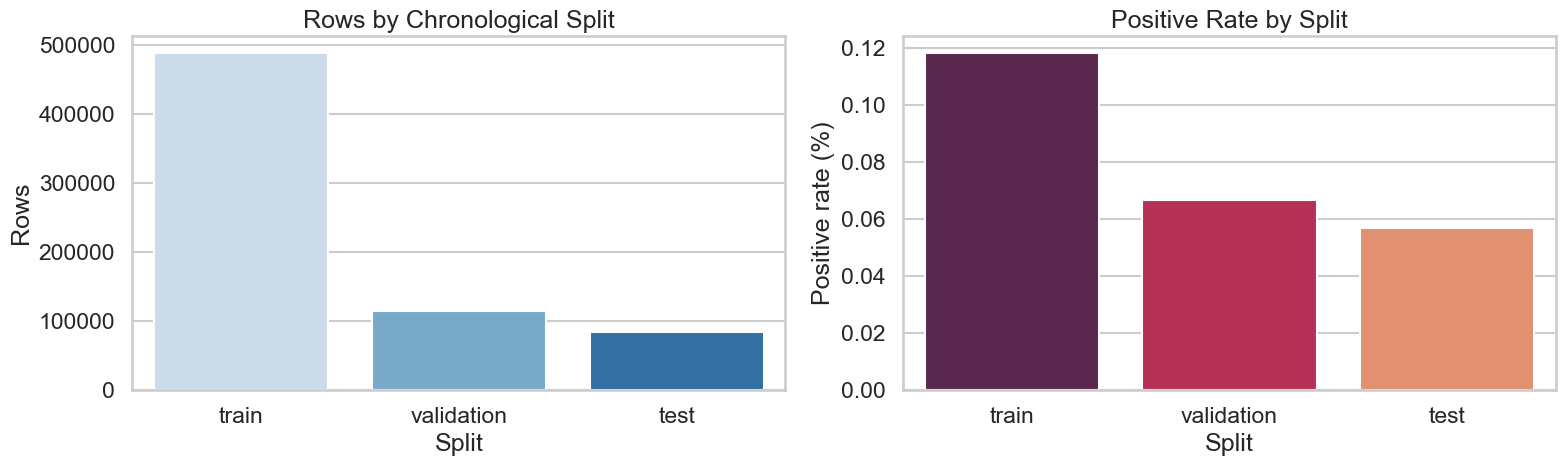

In [5]:
split_plot_df = split_summary.copy()
split_plot_df['positive_rate_percent'] = split_plot_df['positive_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=split_plot_df, x='split', y='rows', hue='split', dodge=False, legend=False, ax=axes[0], palette='Blues')
axes[0].set_title('Rows by Chronological Split')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Rows')

sns.barplot(data=split_plot_df, x='split', y='positive_rate_percent', hue='split', dodge=False, legend=False, ax=axes[1], palette='rocket')
axes[1].set_title('Positive Rate by Split')
axes[1].set_xlabel('Split')
axes[1].set_ylabel('Positive rate (%)')

plt.tight_layout()
fig.savefig(split_plot_path, bbox_inches='tight')
plt.show()

In [6]:
categorical_features = ['node']
numeric_features = [column for column in feature_columns if column not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'categorical',
            OneHotEncoder(handle_unknown='ignore', sparse_output=True),
            categorical_features,
        ),
        (
            'numeric',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler()),
                ]
            ),
            numeric_features,
        ),
    ]
)

model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            LinearSVC(
                C=C_VALUE,
                class_weight='balanced',
                dual='auto',
                max_iter=MAX_ITER,
                tol=TOL,
                random_state=RANDOM_STATE,
                verbose=MODEL_VERBOSE,
            ),
        ),
    ]
)

model_pipeline.fit(X_train, y_train)
trained_linear_svc = model_pipeline.named_steps['model']
fitted_preprocessor = model_pipeline.named_steps['preprocessor']
feature_importance = pd.DataFrame({
    'feature': fitted_preprocessor.get_feature_names_out(),
    'coefficient': trained_linear_svc.coef_.ravel(),
})
feature_importance['abs_coefficient'] = feature_importance['coefficient'].abs()
feature_importance = feature_importance.sort_values('abs_coefficient', ascending=False)
feature_importance.to_csv(feature_importance_path, index=False)

print('LinearSVC fitted successfully.')
print(f'Iterations completed: {int(np.max(trained_linear_svc.n_iter_))} / {MAX_ITER}')
print(f'Feature count after preprocessing: {len(feature_importance)}')

run_metadata = pd.DataFrame([
    {
        'model_name': RESULTS_MODEL_NAME,
        'target_column': TARGET_COLUMN,
        'C_value': C_VALUE,
        'max_iter': MAX_ITER,
        'tol': TOL,
        'iterations_completed': int(np.max(trained_linear_svc.n_iter_)),
        'train_rows': len(train_df),
        'validation_rows': len(valid_df),
        'test_rows': len(test_df),
        'train_positive_rate': float(y_train.mean()),
        'validation_positive_rate': float(y_valid.mean()),
        'test_positive_rate': float(y_test.mean()),
    }
])
run_metadata.to_csv(run_metadata_path, index=False)

display(feature_importance.head(15))


[LibLinear]LinearSVC fitted successfully.
Iterations completed: 14 / 5000
Feature count after preprocessing: 289


,feature,coefficient,abs_coefficient
286,numeric__cpu_time_share_system,-5.288333,5.288333
55,categorical__node_55,-1.373845,1.373845
0,categorical__node_0,1.319417,1.319417
29,categorical__node_29,1.294769,1.294769
9,categorical__node_9,1.257806,1.257806
213,categorical__node_213,-1.230208,1.230208
69,categorical__node_69,-1.205580,1.205580
216,categorical__node_216,-1.200975,1.200975
249,categorical__node_249,-1.190586,1.190586
192,categorical__node_192,1.187652,1.187652


In [7]:
def precision_at_k(y_true, scores, k=50):
    if len(scores) == 0:
        return np.nan
    k = min(k, len(scores))
    top_indices = np.argsort(scores)[::-1][:k]
    return float(np.asarray(y_true)[top_indices].mean())

def evaluate_scores(y_true, scores, threshold):
    predictions = (scores >= threshold).astype(int)
    return {
        'pr_auc': average_precision_score(y_true, scores),
        'roc_auc': roc_auc_score(y_true, scores),
        'precision': precision_score(y_true, predictions, zero_division=0),
        'recall': recall_score(y_true, predictions, zero_division=0),
        'f1': f1_score(y_true, predictions, zero_division=0),
        'predicted_positives': int(predictions.sum()),
        'precision_at_50': precision_at_k(y_true, scores, k=50),
    }

valid_scores = model_pipeline.decision_function(X_valid)
precision_curve, recall_curve, threshold_curve = precision_recall_curve(y_valid, valid_scores)
f1_curve = 2 * precision_curve[:-1] * recall_curve[:-1] / np.clip(precision_curve[:-1] + recall_curve[:-1], 1e-12, None)
best_threshold = float(threshold_curve[np.nanargmax(f1_curve)]) if len(threshold_curve) else 0.5

validation_results = pd.DataFrame([
    {'threshold': 0.00, **evaluate_scores(y_valid, valid_scores, 0.00)},
    {'threshold': best_threshold, **evaluate_scores(y_valid, valid_scores, best_threshold)},
])

validation_results.to_csv(validation_metrics_path, index=False)

display(validation_results)

,threshold,pr_auc,roc_auc,precision,recall,f1,predicted_positives,precision_at_50
0,0.000000,0.000995,0.502451,0.000698,0.355263,0.001392,38707,0.0
1,1.239688,0.000995,0.502451,0.015385,0.013158,0.014184,65,0.0


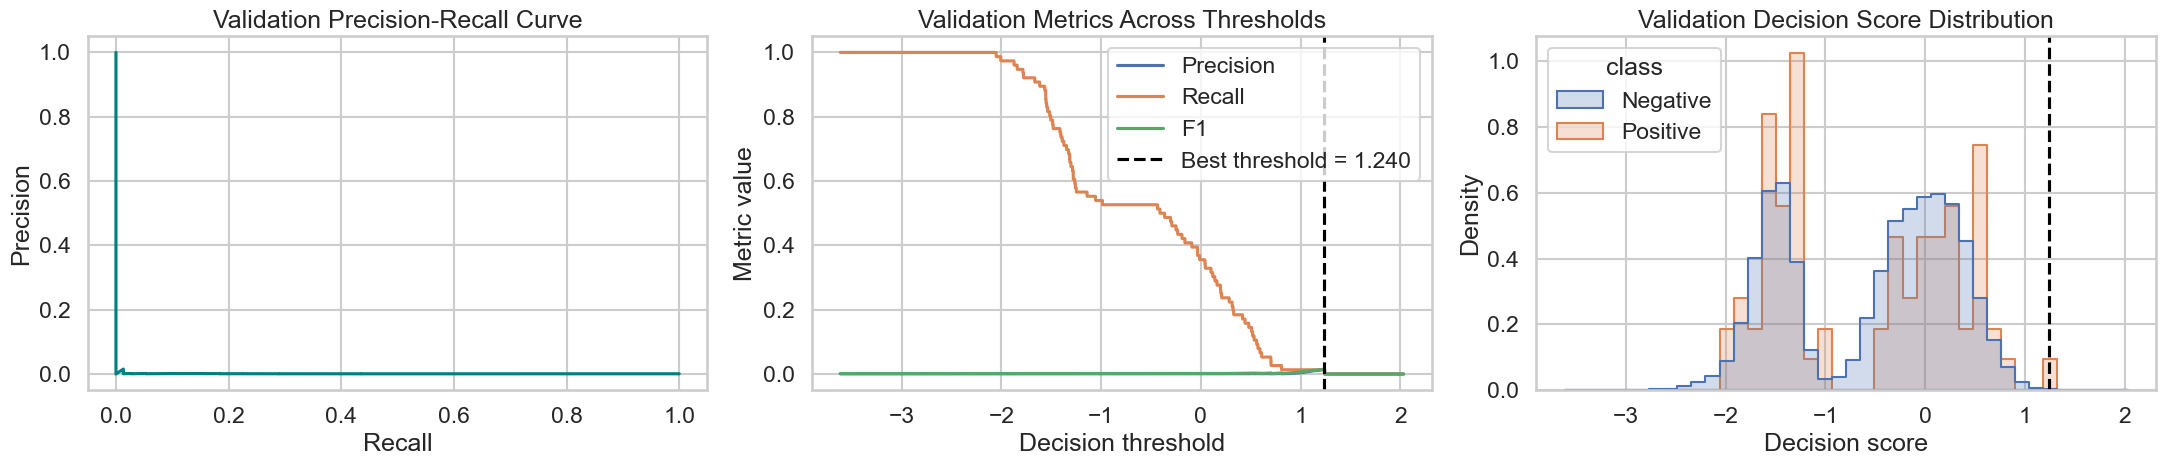

In [8]:
validation_curve_df = pd.DataFrame({
    'threshold': threshold_curve,
    'precision': precision_curve[:-1],
    'recall': recall_curve[:-1],
    'f1': f1_curve,
})

valid_plot_df = pd.DataFrame({
    'score': valid_scores,
    'class': np.where(y_valid.to_numpy() == 1, 'Positive', 'Negative'),
})

validation_curve_df.to_csv(validation_curve_path, index=False)

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
axes[0].plot(recall_curve, precision_curve, color='teal')
axes[0].set_title('Validation Precision-Recall Curve')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')

axes[1].plot(validation_curve_df['threshold'], validation_curve_df['precision'], label='Precision')
axes[1].plot(validation_curve_df['threshold'], validation_curve_df['recall'], label='Recall')
axes[1].plot(validation_curve_df['threshold'], validation_curve_df['f1'], label='F1')
axes[1].axvline(best_threshold, color='black', linestyle='--', label=f'Best threshold = {best_threshold:.3f}')
axes[1].set_title('Validation Metrics Across Thresholds')
axes[1].set_xlabel('Decision threshold')
axes[1].set_ylabel('Metric value')
axes[1].legend()

sns.histplot(data=valid_plot_df, x='score', hue='class', bins=40, stat='density', common_norm=False, element='step', ax=axes[2])
axes[2].axvline(best_threshold, color='black', linestyle='--')
axes[2].set_title('Validation Decision Score Distribution')
axes[2].set_xlabel('Decision score')
axes[2].set_ylabel('Density')

plt.tight_layout()
fig.savefig(validation_plot_path, bbox_inches='tight')
plt.show()


In [9]:
test_scores = model_pipeline.decision_function(X_test)
test_results = pd.DataFrame([
    {'threshold': 0.00, **evaluate_scores(y_test, test_scores, 0.00)},
    {'threshold': best_threshold, **evaluate_scores(y_test, test_scores, best_threshold)},
])

test_risk_scores = test_df[['node', 'hour', TARGET_COLUMN]].copy()
test_risk_scores['risk_score'] = test_scores
top_risk_rows = test_risk_scores.sort_values('risk_score', ascending=False).head(20)

test_results.to_csv(test_metrics_path, index=False)
test_risk_scores.to_csv(test_risk_scores_path, index=False, compression='gzip')
top_risk_rows.to_csv(top_risk_rows_path, index=False)

display(test_results)

display(top_risk_rows)

,threshold,pr_auc,roc_auc,precision,recall,f1,predicted_positives,precision_at_50
0,0.000000,0.001066,0.531084,0.000735,0.395833,0.001467,25855,0.0
1,1.239688,0.001066,0.531084,0.000000,0.000000,0.000000,42,0.0


,node,hour,label_next_6h,risk_score
587380,219,2005-09-24 06:00:00,0,5.165820
590176,220,2005-09-24 06:00:00,0,5.055306
40879,17,2005-09-02 04:00:00,0,4.657301
581800,217,2005-09-24 06:00:00,0,3.943906
579019,216,2005-09-24 06:00:00,0,3.538602
22436,5,2005-08-22 18:00:00,0,3.360466
38338,15,2005-08-26 04:00:00,0,2.981203
6632,0,2005-08-10 05:00:00,0,2.968196
6657,0,2005-08-12 00:00:00,0,2.840630
510363,192,2005-09-02 09:00:00,0,2.546523


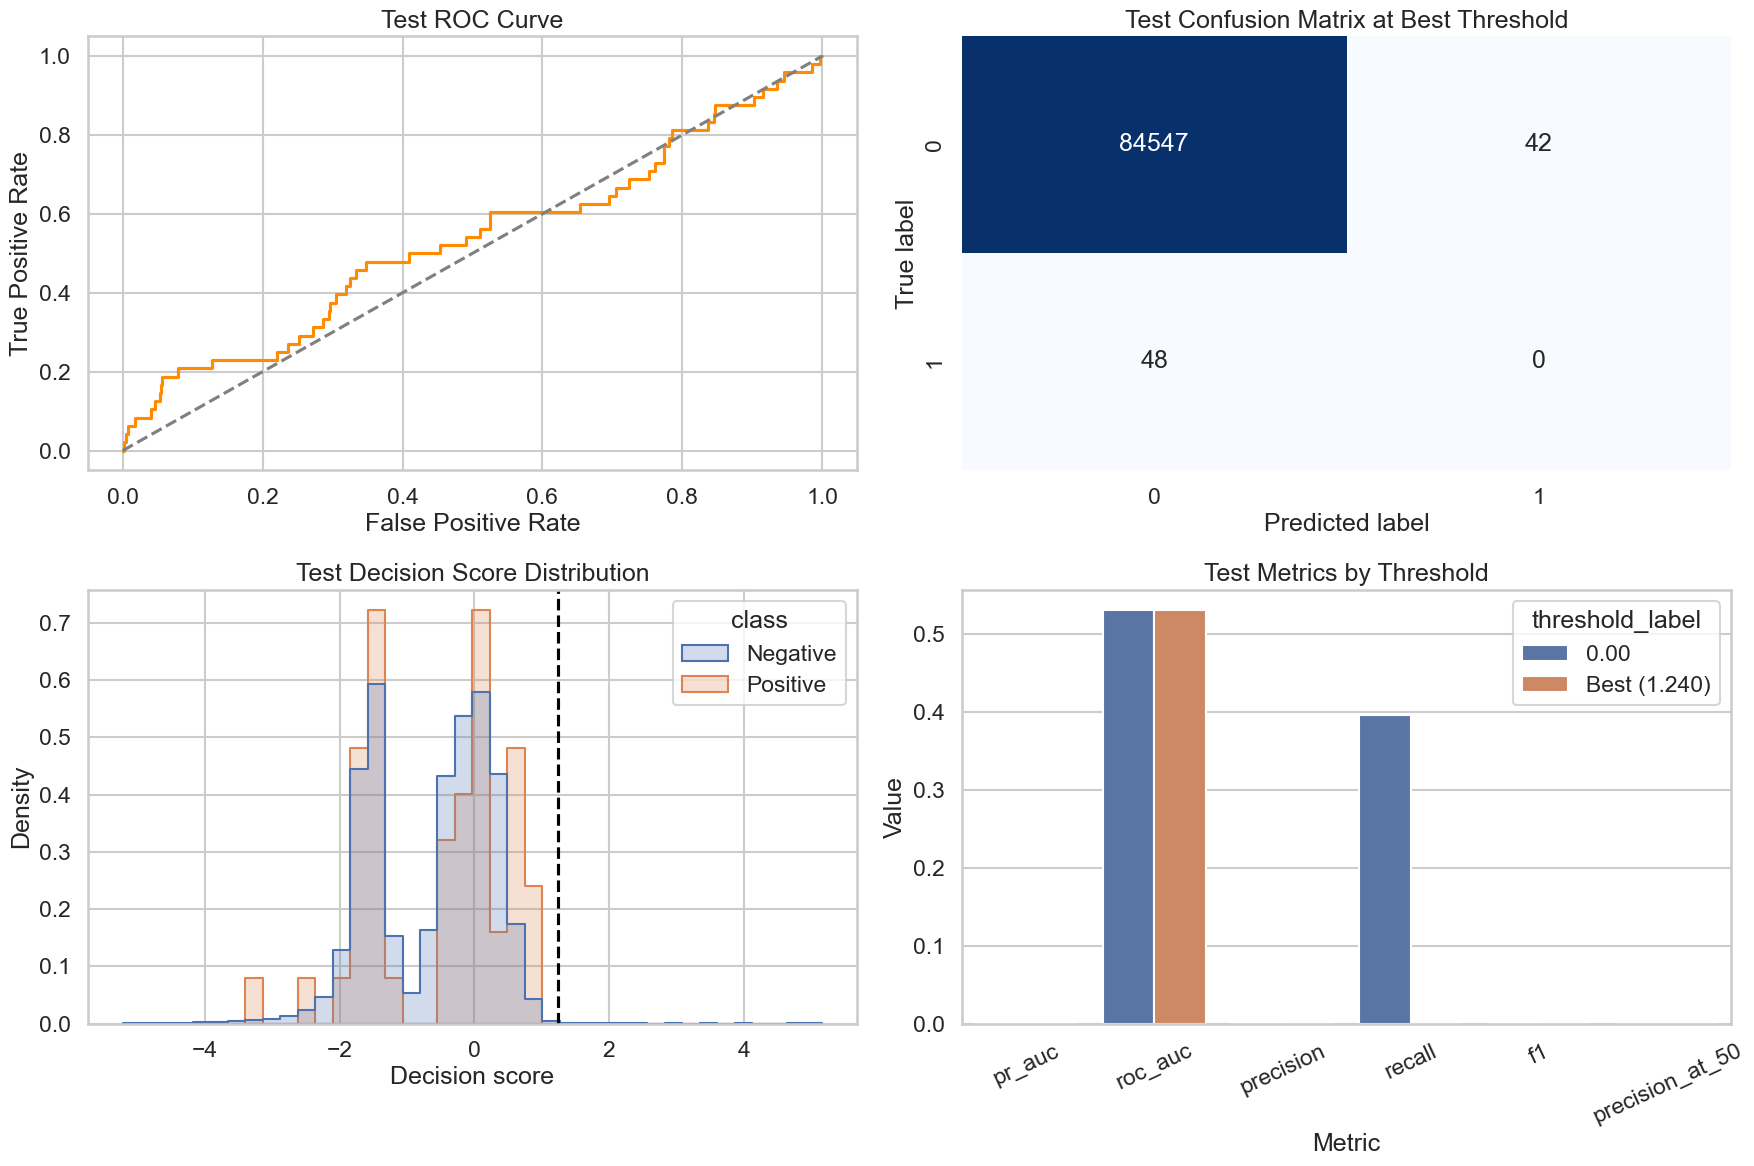

In [10]:
fpr, tpr, _ = roc_curve(y_test, test_scores)
test_predictions_best = (test_scores >= best_threshold).astype(int)
cm = confusion_matrix(y_test, test_predictions_best)

test_plot_df = pd.DataFrame({
    'score': test_scores,
    'class': np.where(y_test.to_numpy() == 1, 'Positive', 'Negative'),
})

metrics_plot_df = test_results.melt(
    id_vars='threshold',
    value_vars=['pr_auc', 'roc_auc', 'precision', 'recall', 'f1', 'precision_at_50'],
    var_name='metric',
    value_name='value',
)
metrics_plot_df['threshold_label'] = metrics_plot_df['threshold'].map(lambda value: '0.00' if value == 0.0 else f'Best ({value:.3f})')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes[0, 0].plot(fpr, tpr, color='darkorange')
axes[0, 0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0, 0].set_title('Test ROC Curve')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0, 1])
axes[0, 1].set_title('Test Confusion Matrix at Best Threshold')
axes[0, 1].set_xlabel('Predicted label')
axes[0, 1].set_ylabel('True label')

sns.histplot(data=test_plot_df, x='score', hue='class', bins=40, stat='density', common_norm=False, element='step', ax=axes[1, 0])
axes[1, 0].axvline(best_threshold, color='black', linestyle='--')
axes[1, 0].set_title('Test Decision Score Distribution')
axes[1, 0].set_xlabel('Decision score')
axes[1, 0].set_ylabel('Density')

sns.barplot(data=metrics_plot_df, x='metric', y='value', hue='threshold_label', ax=axes[1, 1])
axes[1, 1].set_title('Test Metrics by Threshold')
axes[1, 1].set_xlabel('Metric')
axes[1, 1].set_ylabel('Value')
axes[1, 1].tick_params(axis='x', rotation=25)

plt.tight_layout()
fig.savefig(test_plot_path, bbox_inches='tight')
plt.show()


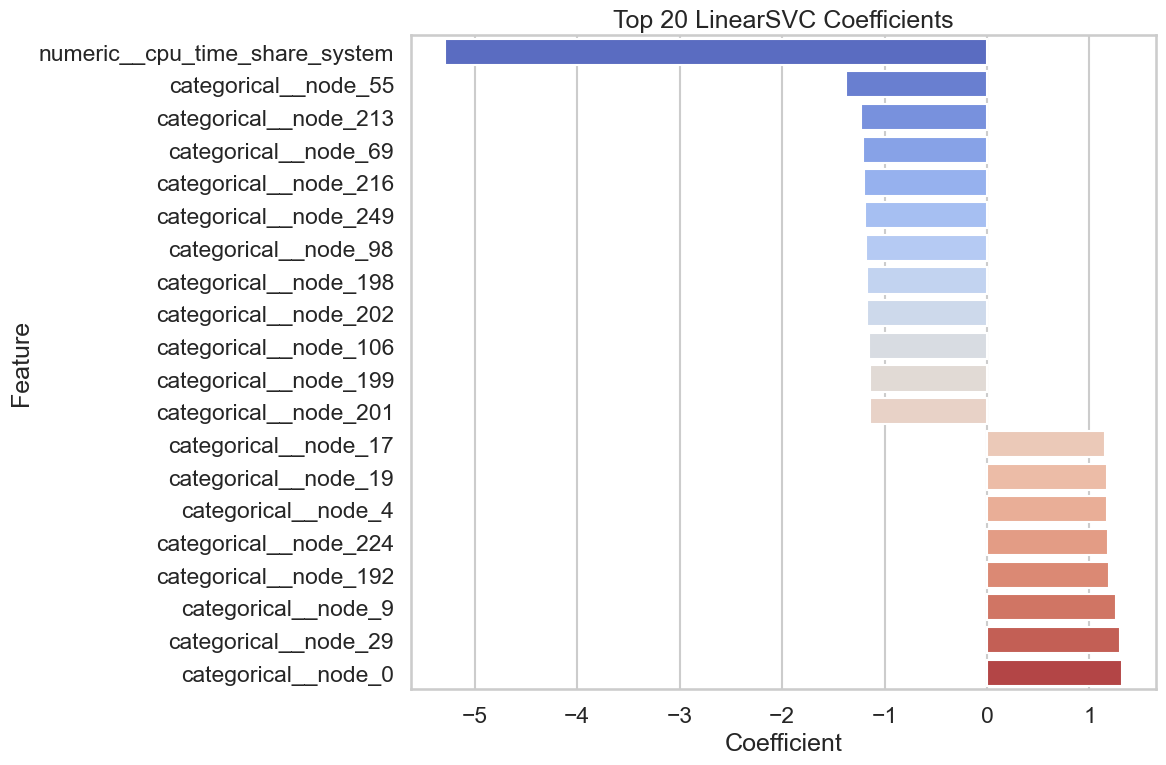

In [11]:
top_feature_importance = feature_importance.head(20).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=top_feature_importance, x='coefficient', y='feature', hue='feature', dodge=False, legend=False, palette='coolwarm', ax=ax)
ax.set_title('Top 20 LinearSVC Coefficients')
ax.set_xlabel('Coefficient')
ax.set_ylabel('Feature')
plt.tight_layout()
fig.savefig(feature_importance_plot_path, bbox_inches='tight')
plt.show()

## Summary

This notebook extends the modeling stage from [07_extra_trees.ipynb](07_extra_trees.ipynb) by testing a margin-based linear SVM under the same chronological split and saved-results contract. LinearSVC is a useful final linear benchmark because it can scale to this dataset size, but its decision scores should be interpreted as relative ranking signals rather than calibrated probabilities.

Saved comparison artifacts for this run are written to `results/linear_svc/`, including coefficient-based feature-importance outputs.